# Association Rules Mining (Apriori)

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [41]:
import pandas as pd


raw_df = pd.read_csv("D:\SEM4\ml\lab\dataset\8th\Groceries_dataset.csv")

print("Dataset shape:", raw_df.shape)
display(raw_df.head())
print("Columns:", list(raw_df.columns))

Dataset shape: (38765, 3)


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


Columns: ['Member_number', 'Date', 'itemDescription']


In [42]:
# 2) Data preprocessing: convert to transaction list and one-hot encoding
# This block supports common formats:
# A) One row per item with [Transaction ID, Item]
# B) One row per transaction with items in a single comma-separated field

# Normalize column names for robust detection
working_df = raw_df.copy()
working_df.columns = [c.strip().lower().replace(" ", "_") for c in working_df.columns]

possible_tx_cols = ["transaction_id", "transaction", "txn_id", "invoice_no", "invoice", "bill_no", "order_id", "tid"]
possible_item_cols = ["items_purchased", "items", "item", "product", "product_name", "description"]

tx_col = next((c for c in possible_tx_cols if c in working_df.columns), None)
item_col = next((c for c in possible_item_cols if c in working_df.columns), None)

if item_col is None:
    # Fallback: choose the first non-transaction column as item column
    non_tx_cols = [c for c in working_df.columns if c != tx_col]
    if non_tx_cols:
        item_col = non_tx_cols[0]
    else:
        raise ValueError("Could not detect an item column in the dataset.")

# Build transactions list
transactions = []

# Case B: one row has multiple items in a string
if working_df[item_col].astype(str).str.contains(",|;|\|").any():
    for _, row in working_df.iterrows():
        items = [i.strip() for i in str(row[item_col]).replace(";", ",").replace("|", ",").split(",") if i.strip()]
        if items:
            transactions.append(sorted(list(set(items))))

# Case A: transaction-item rows
elif tx_col is not None and working_df[[tx_col, item_col]].dropna().shape[0] > 0:
    grouped = (
        working_df[[tx_col, item_col]]
        .dropna()
        .astype({item_col: str})
        .groupby(tx_col)[item_col]
        .apply(lambda x: sorted(list(set(i.strip() for i in x if str(i).strip()))))
    )
    transactions = [items for items in grouped.tolist() if len(items) > 0]

# Last fallback: each row is treated as one transaction with one item
else:
    transactions = [[str(v).strip()] for v in working_df[item_col].dropna().tolist() if str(v).strip()]

print("Detected transaction column:", tx_col)
print("Detected item column:", item_col)
print("Number of transactions:", len(transactions))
print("Sample transactions:", transactions[:5])

# One-hot encoding for Apriori
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

print("One-hot encoded shape:", basket_df.shape)
display(basket_df.head())

Detected transaction column: None
Detected item column: member_number
Number of transactions: 38765
Sample transactions: [['1808'], ['2552'], ['2300'], ['1187'], ['3037']]
One-hot encoded shape: (38765, 3898)


,1000,1001,1002,1003,1004,1005,1006,1008,1009,1010,...,4991,4992,4993,4994,4995,4996,4997,4998,4999,5000
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [43]:
# 3) Generate frequent itemsets using Apriori
min_support = 0.02  # You can change this value

frequent_itemsets = apriori(
    basket_df,
    min_support=min_support,
    use_colnames=True,
    low_memory=True
)

print(f"Minimum support: {min_support}")
print("Number of frequent itemsets:", len(frequent_itemsets))

if len(frequent_itemsets) == 0:
    print("\n⚠️ WARNING: No frequent itemsets found!")
    print("Try lowering min_support (e.g., 0.01, 0.005) to find itemsets.")
else:
    frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
    frequent_itemsets = frequent_itemsets.sort_values(["support", "length"], ascending=[False, True]).reset_index(drop=True)
    display(frequent_itemsets.head(15))

Minimum support: 0.02
Number of frequent itemsets: 0

⚠️ WARNING: No frequent itemsets found!
Try lowering min_support (e.g., 0.01, 0.005) to find itemsets.


In [44]:
# 4) Visualization: bar chart of frequent itemsets (top single items)
if len(frequent_itemsets) == 0:
    print("No frequent itemsets found. Cannot create visualization.")
else:
    single_itemsets = frequent_itemsets[frequent_itemsets["length"] == 1].copy()
    
    if len(single_itemsets) == 0:
        print("No single items found. Try lowering min_support.")
    else:
        single_itemsets["item"] = single_itemsets["itemsets"].apply(lambda x: list(x)[0])
        plot_df = single_itemsets.sort_values("support", ascending=False).head(15)

        plt.figure(figsize=(12, 6))
        sns.barplot(data=plot_df, x="item", y="support", palette="viridis")
        plt.title("Top Frequent Single Items by Support")
        plt.xlabel("Item")
        plt.ylabel("Support")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

No frequent itemsets found. Cannot create visualization.


In [45]:
# 5) Generate association rules and filter by confidence + lift
min_confidence = 0.40
min_lift = 1.10

if len(frequent_itemsets) == 0:
    print("No frequent itemsets found. Try lowering min_support in the previous cell.")
    rules = pd.DataFrame(columns=["support", "confidence", "lift", "antecedents", "consequents"])
else:
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)

if not rules.empty:
    rules = rules.sort_values(["lift", "confidence", "support"], ascending=[False, False, False]).reset_index(drop=True)

filtered_rules = rules[(rules["confidence"] >= min_confidence) & (rules["lift"] >= min_lift)].copy() if not rules.empty else pd.DataFrame()

# Make antecedents/consequents readable
for col in ["antecedents", "consequents"]:
    if col in filtered_rules.columns and len(filtered_rules) > 0:
        filtered_rules[col] = filtered_rules[col].apply(lambda x: ", ".join(sorted(list(x))))

print("Total generated rules:", len(rules))
print("Filtered strong rules:", len(filtered_rules))

if len(filtered_rules) > 0:
    display_cols = ["antecedents", "consequents", "support", "confidence", "lift"]
    display(filtered_rules[display_cols].head(20))
else:
    print("No rules generated. Try lowering min_support or min_confidence.")

No frequent itemsets found. Try lowering min_support in the previous cell.
Total generated rules: 0
Filtered strong rules: 0
No rules generated. Try lowering min_support or min_confidence.


In [46]:
# 6) Compare rules with different confidence levels
confidence_levels = [0.2, 0.4, 0.6, 0.8]
comparison_rows = []

if len(frequent_itemsets) > 0:
    for conf in confidence_levels:
        r = association_rules(frequent_itemsets, metric="confidence", min_threshold=conf)
        strong = r[r["lift"] >= 1.0] if not r.empty else r
        comparison_rows.append({
            "confidence_threshold": conf,
            "num_rules": len(r),
            "num_rules_lift>=1": len(strong)
        })

    confidence_comparison = pd.DataFrame(comparison_rows)
    display(confidence_comparison)

    plt.figure(figsize=(9, 5))
    sns.lineplot(data=confidence_comparison, x="confidence_threshold", y="num_rules", marker="o", label="All Rules")
    sns.lineplot(data=confidence_comparison, x="confidence_threshold", y="num_rules_lift>=1", marker="o", label="Rules with lift >= 1")
    plt.title("Effect of Confidence Threshold on Number of Rules")
    plt.xlabel("Confidence Threshold")
    plt.ylabel("Number of Rules")
    plt.tight_layout()
    plt.show()
else:
    print("No frequent itemsets found. Cannot generate rules. Lower min_support in an earlier cell.")

No frequent itemsets found. Cannot generate rules. Lower min_support in an earlier cell.


,support_threshold,num_itemsets,num_2plus_itemsets
0,0.01,0,0
1,0.02,0,0
2,0.03,0,0
3,0.05,0,0
4,0.10,0,0


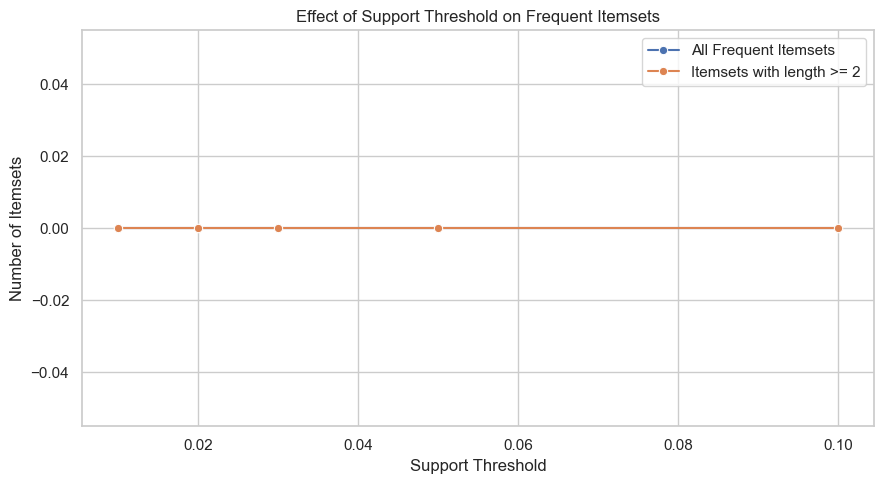

In [47]:
# 7) Observe effect of support threshold on frequent itemsets
support_levels = [0.01, 0.02, 0.03, 0.05, 0.1]
support_rows = []

for s in support_levels:
    fi = apriori(basket_df, min_support=s, use_colnames=True, low_memory=True)
    fi["length"] = fi["itemsets"].apply(len)
    support_rows.append({
        "support_threshold": s,
        "num_itemsets": len(fi),
        "num_2plus_itemsets": int((fi["length"] >= 2).sum())
    })

support_comparison = pd.DataFrame(support_rows)
display(support_comparison)

plt.figure(figsize=(9, 5))
sns.lineplot(data=support_comparison, x="support_threshold", y="num_itemsets", marker="o", label="All Frequent Itemsets")
sns.lineplot(data=support_comparison, x="support_threshold", y="num_2plus_itemsets", marker="o", label="Itemsets with length >= 2")
plt.title("Effect of Support Threshold on Frequent Itemsets")
plt.xlabel("Support Threshold")
plt.ylabel("Number of Itemsets")
plt.tight_layout()
plt.show()

In [48]:
# 8) Visualization: network graph of association rules
# If strict filters produce no rules, fall back to top rules for visualization.
if len(filtered_rules) > 0:
    top_rules = filtered_rules.head(20).copy()
elif len(rules) > 0:
    print("No strong filtered rules found; showing top unfiltered rules instead.")
    top_rules = rules.head(20).copy()
    # Make sets readable for plotting labels
    for col in ["antecedents", "consequents"]:
        if col in top_rules.columns:
            top_rules[col] = top_rules[col].apply(lambda x: ", ".join(sorted(list(x))))
else:
    print("No association rules available for graph. Lower min_support/min_confidence and rerun.")
    top_rules = pd.DataFrame()

if len(top_rules) > 0:
    G = nx.DiGraph()

    # Build directed graph: antecedent -> consequent with edge weight as lift
    for _, row in top_rules.iterrows():
        ant = row["antecedents"]
        con = row["consequents"]
        lift_val = float(row["lift"])
        conf_val = float(row["confidence"])

        G.add_node(ant, kind="antecedent")
        G.add_node(con, kind="consequent")
        G.add_edge(ant, con, weight=lift_val, confidence=conf_val)

    plt.figure(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=1.2)

    node_colors = ["#2a9d8f" if G.nodes[n].get("kind") == "antecedent" else "#e76f51" for n in G.nodes()]
    edge_widths = [1 + 2 * G[u][v]["weight"] / max(1, top_rules["lift"].max()) for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=9)
    nx.draw_networkx_edges(G, pos, width=edge_widths, arrows=True, arrowstyle="->", arrowsize=15, alpha=0.6)

    plt.title("Association Rules Network (Top Rules by Lift)")
    plt.axis("off")
    plt.show()

No association rules available for graph. Lower min_support/min_confidence and rerun.


In [49]:
# 10) Final snapshot: strongest rules by lift/confidence
if len(filtered_rules) > 0:
    final_view = filtered_rules.sort_values(["lift", "confidence", "support"], ascending=False)
    display(final_view[["antecedents", "consequents", "support", "confidence", "lift"]].head(15))
else:
    print("No strong rules found with current thresholds. Try min_support=0.01, min_confidence=0.2, min_lift=1.0")

No strong rules found with current thresholds. Try min_support=0.01, min_confidence=0.2, min_lift=1.0
